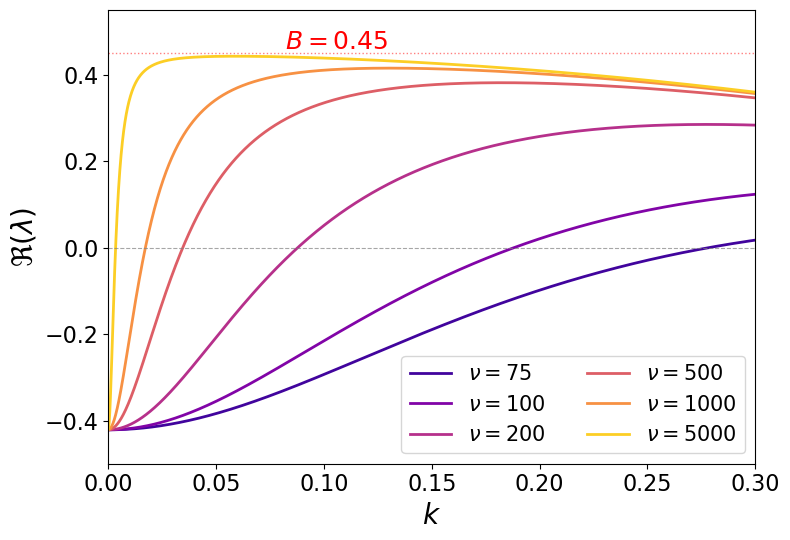

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

#Parameters
A = 2.0
B = 0.45
d = 500.0

#Compute the larger vegetated steady state u*
u_star = (A + np.sqrt(A**2 - 4*B**2)) / (2*B)
w_star = B / u_star

#Computes Real(lambda)
def exact_Re_lambda(k, nu, A, B, d, u_s): 
    alpha = ((1 + d)*k**2 + (1 + u_s**2) - B)**2 - k**2*nu**2 - 4*(k**2*(d*k**2 + 1 + u_s**2 + B*d) + B*(u_s**2 - 1))
    
    beta = 2*k*nu * ((1 - d)*k**2 - (B + u_s**2 + 1))
    
    mod = np.sqrt(alpha**2 + beta**2)
    sqrt_real = np.sqrt(0.5*(mod + alpha))
    
    re_lam = 0.5 * (B - (1 + d)*k**2 - (1 + u_s**2) + sqrt_real)
    
    return re_lam

#Plotting
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))

d_plot = 1.0
nu_values_zoom = [75, 100, 200, 500, 1000, 5000]
colors_zoom = plt.cm.plasma(np.linspace(0.1, 0.9, len(nu_values_zoom)))
k_range_zoom = np.linspace(1e-6, 0.3, 2000)

for nu, col in zip(nu_values_zoom, colors_zoom):
    re_lam = exact_Re_lambda(k_range_zoom, nu, A, B, d_plot, u_star)
    ax.plot(k_range_zoom, re_lam, color=col, linewidth=2.0, label=f'$\\nu = {nu}$')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=B, color='red', linestyle=':', linewidth=1.0, alpha=0.5)
ax.text(0.13, B + 0.01, f'$B = {B}$', color='red', fontsize=18, ha='right')

ax.set_xlabel('$k$', fontsize=20)
ax.set_ylabel('$\\Re(\\lambda)$', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=15, ncol=2)
ax.set_ylim(-0.5, 0.55)
ax.set_xlim(0, 0.3)

plt.tight_layout()
plt.savefig('fig_boundary_layer_zoom.pdf', dpi=200, bbox_inches='tight')
plt.show()